# Recurrence Quantification Analysis of Beijing PM2.5 (2010–2014)

**Module 6 — Complex Systems | Recurrence Quantification Analysis**

---

## Dataset

Dataset used: [Beijing PM2.5 Data — UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/381/beijing+pm2+5+data)

**Source:** Liang et al. (2015) — Assessing Beijing's PM2.5 pollution: Severity, weather impact, APEC and winter heating.

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [60]:
# Load the dataset
df = pd.read_csv('PRSA_data_2010.1.1-2014.12.31.csv')


print("shape: ", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

shape:  (43824, 13)

Column names: ['No', 'year', 'month', 'day', 'hour', 'pm2.5', 'DEWP', 'TEMP', 'PRES', 'cbwd', 'Iws', 'Is', 'Ir']

First 5 rows:


,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


In [61]:
#clean and preprocess the data


df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# Step 2: Set datetime as the index
df = df.set_index('datetime')

# Step 3: Keep only the columns we need
df = df[['pm2.5', 'TEMP', 'PRES', 'Iws']]

# Step 4: Rename for convenience
df.columns = ['pm25', 'temp', 'pressure', 'wind']

# Step 5: Check how many missing values we have
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal rows: {len(df)}")


Missing values per column:
pm25        2067
temp           0
pressure       0
wind           0
dtype: int64

Total rows: 43824


In [62]:
df = df.fillna(method='ffill')

# Step 2: Check no missing values remain
print("Missing values after filling:")
print(df.isnull().sum())

# Step 3: Resample hourly data to daily averages
df_daily = df.resample('D').mean()

print(f"\nHourly data points: {len(df)}")
print(f"Daily data points:  {len(df_daily)}")
print("\nFirst 5 daily rows:")
df_daily.head()

Missing values after filling:
pm25        24
temp         0
pressure     0
wind         0
dtype: int64

Hourly data points: 43824
Daily data points:  1826

First 5 daily rows:


,pm25,temp,pressure,wind
datetime,,,,
2010-01-01,NaN,-6.750000,1017.083333,14.458333
2010-01-02,145.958333,-5.125000,1024.750000,24.860000
2010-01-03,78.833333,-8.541667,1022.791667,70.937917
2010-01-04,31.333333,-11.500000,1029.291667,111.160833
2010-01-05,42.458333,-14.458333,1033.625000,56.920000


In [63]:
df_daily = df_daily.bfill()

# Confirm everything is clean
print("Missing values after backward fill:")
print(df_daily.isnull().sum())
print(f"\nDate range: {df_daily.index[0]} to {df_daily.index[-1]}")
print(f"\nBasic statistics:")
df_daily.describe().round(2)

Missing values after backward fill:
pm25        0
temp        0
pressure    0
wind        0
dtype: int64

Date range: 2010-01-01 00:00:00 to 2014-12-31 00:00:00

Basic statistics:


,pm25,temp,pressure,wind
count,1826.00,1826.00,1826.00,1826.00
mean,97.81,12.45,1016.45,23.89
std,76.96,11.56,10.07,41.36
min,2.96,-14.46,994.04,1.41
25%,41.65,1.54,1007.94,5.91
50%,78.56,13.90,1016.23,10.95
75%,131.04,23.17,1024.53,22.23
max,541.04,32.88,1043.46,463.19


In [64]:
pip install kaleido

Note: you may need to restart the kernel to use updated packages.


In [65]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

variables = ['pm25', 'temp', 'pressure', 'wind']
colors    = ['#1a5276', '#117a65', '#e67e22', '#8e44ad']
labels    = ['PM2.5 (μg/m³)', 'Temperature (°C)', 'Pressure (hPa)', 'Wind Speed (m/s)']

fig = make_subplots(
    rows=4, cols=1,
    shared_xaxes=True,
    subplot_titles=labels,
    vertical_spacing=0.06
)

for i, (var, color, label) in enumerate(zip(variables, colors, labels), start=1):
    # Raw daily signal
    fig.add_trace(go.Scatter(
        x=df_daily.index,
        y=df_daily[var],
        mode='lines',
        name=f'{label} (daily)',
        line=dict(color=color, width=0.8),
        opacity=0.4,
        legendgroup=var,
    ), row=i, col=1)

    # 30-day rolling mean
    rolling = df_daily[var].rolling(window=30, center=True).mean()
    fig.add_trace(go.Scatter(
        x=df_daily.index,
        y=rolling,
        mode='lines',
        name=f'{label} (30d mean)',
        line=dict(color=color, width=2.5),
        legendgroup=var,
    ), row=i, col=1)

fig.update_layout(
    height=900,
    title=dict(
        text='Beijing Air Quality — Daily Averages (2010–2014)<br>'
             '<sup>Zoom, pan, or hover over any point to explore</sup>',
        font=dict(size=16)
    ),
    hovermode='x unified',   # shows all 4 values when you hover on a date
    template='plotly_white',
    legend=dict(orientation='h', y=-0.05)
)

# Save as interactive HTML file you can open in any browser
fig.write_html('beijing_interactive.html')
fig.write_image('beijing_raw.png', width=1400, height=900, scale=2)

fig.show()


In [66]:
# Z-score normalize all variables
def zscore(series):
    return (series - series.mean()) / series.std()

df_norm = df_daily.copy()
df_norm['pm25']     = zscore(df_daily['pm25'])
df_norm['temp']     = zscore(df_daily['temp'])
df_norm['pressure'] = zscore(df_daily['pressure'])
df_norm['wind']     = zscore(df_daily['wind'])

print("After normalization — mean and std of each variable:")
print(df_norm.describe().round(3).loc[['mean','std']])

After normalization — mean and std of each variable:
      pm25  temp  pressure  wind
mean  -0.0   0.0       0.0   0.0
std    1.0   1.0       1.0   1.0


Optimal delay τ = 4 days


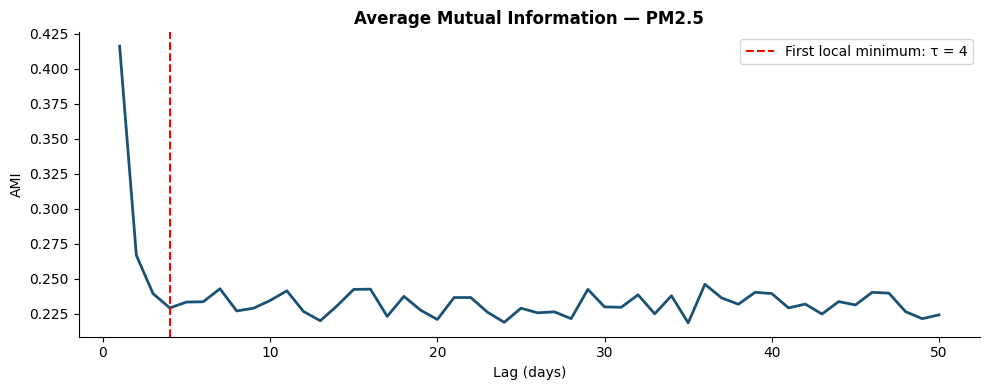

 τ = 4


In [67]:
def compute_ami(ts, max_lag=50):
    """
    Average Mutual Information.
    We want the FIRST LOCAL MINIMUM — that's our optimal tau.
    """
    bins = int(np.sqrt(len(ts)))
    ami_vals = []
    
    for lag in range(1, max_lag + 1):
        x = ts[:-lag]
        y = ts[lag:]
        
        # Joint histogram
        hist2d, _, _ = np.histogram2d(x, y, bins=bins)
        
        # Convert to probabilities
        pxy = hist2d / hist2d.sum()
        px  = pxy.sum(axis=1)
        py  = pxy.sum(axis=0)
        
        # Mutual information
        mi = 0
        for i in range(len(px)):
            for j in range(len(py)):
                if pxy[i,j] > 0 and px[i] > 0 and py[j] > 0:
                    mi += pxy[i,j] * np.log(pxy[i,j] / (px[i] * py[j]))
        ami_vals.append(mi)
    
    return np.array(ami_vals)

# Run AMI on PM2.5
pm25_vals = df_norm['pm25'].values
ami_vals  = compute_ami(pm25_vals, max_lag=50)

# Find first local minimum — this is our tau
tau = 1
for i in range(1, len(ami_vals) - 1):
    if ami_vals[i] < ami_vals[i-1] and ami_vals[i] < ami_vals[i+1]:
        tau = i + 1
        break

print(f"Optimal delay τ = {tau} days")

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(ami_vals)+1), ami_vals, 
        color='#1a5276', lw=2)
ax.axvline(tau, color='red', ls='--', lw=1.5, 
           label=f'First local minimum: τ = {tau}')
ax.set_title('Average Mutual Information — PM2.5', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('Lag (days)')
ax.set_ylabel('AMI')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig_ami.png', dpi=150, bbox_inches='tight')
plt.show()
print(" τ =", tau)

  M=1: FNN = 65.5%
  M=2: FNN = 62.3%
  M=3: FNN = 19.3%
  M=4: FNN = 3.0%
  M=5: FNN = 0.5%
  M=6: FNN = 0.1%
  M=7: FNN = 0.0%
  M=8: FNN = 0.0%

Optimal embedding dimension M = 4


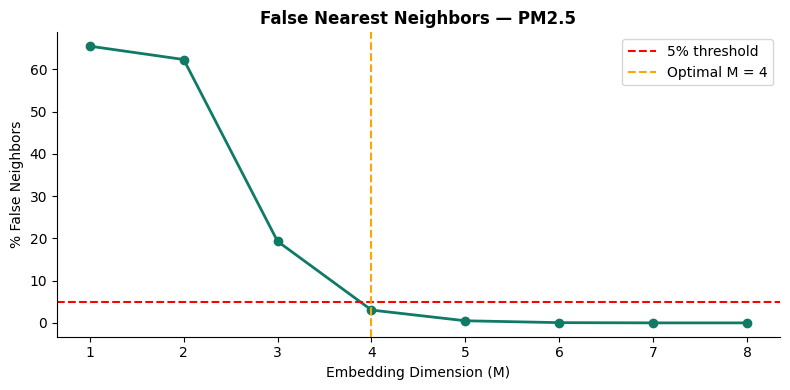

In [68]:
from scipy.spatial.distance import cdist

def compute_fnn(ts, tau, max_m=8, rtol=15):

    fnn_pcts = []
    
    for m in range(1, max_m + 1):
        # Embed in m dimensions
        L = len(ts) - (m) * tau
        X_m  = np.array([ts[i*tau : i*tau + L] for i in range(m)]).T
        X_m1 = np.array([ts[i*tau : i*tau + L] for i in range(m+1)]).T
        
        # Find nearest neighbor for each point in m dimensions
        dist_m = cdist(X_m, X_m, 'euclidean')
        np.fill_diagonal(dist_m, np.inf)
        nn_idx = dist_m.argmin(axis=1)
        
        # Check if neighbor is false in m+1 dimensions
        false_count = 0
        for i in range(len(X_m)):
            j    = nn_idx[i]
            d_m  = dist_m[i, j]
            d_m1 = np.linalg.norm(X_m1[i] - X_m1[j])
            if d_m > 0 and (d_m1 / d_m) > rtol:
                false_count += 1
        
        fnn_pcts.append(false_count / len(X_m) * 100)
        print(f"  M={m}: FNN = {fnn_pcts[-1]:.1f}%")
    
    # Find M where FNN first drops below 5%
    m_opt = max_m
    for i, f in enumerate(fnn_pcts):
        if f < 5:
            m_opt = i + 1
            break
    
    return fnn_pcts, m_opt

# Run FNN using tau we just found

fnn_vals, m_opt = compute_fnn(pm25_vals, tau=tau, max_m=8)

print(f"\nOptimal embedding dimension M = {m_opt}")

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(fnn_vals)+1), fnn_vals,
        color='#117a65', lw=2, marker='o', ms=6)
ax.axhline(5, color='red', ls='--', lw=1.5, label='5% threshold')
ax.axvline(m_opt, color='orange', ls='--', lw=1.5,
           label=f'Optimal M = {m_opt}')
ax.set_title('False Nearest Neighbors — PM2.5',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Embedding Dimension (M)')
ax.set_ylabel('% False Neighbors')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig_fnn.png', dpi=150, bbox_inches='tight')
plt.show()


In [69]:
#finding the Radius

def find_radius(ts, m, tau, target_pct=3.0, tol=0.5, max_iter=50):
    """
    Binary search for radius that gives ~target_pct% recurrence.
    Teacher says 2-5% for behavioral/environmental signals.
    """
    # Build embedded matrix
    L   = len(ts) - (m - 1) * tau
    X   = np.array([ts[i*tau : i*tau + L] for i in range(m)]).T
    
    lo, hi = 0.01, 5.0
    
    for _ in range(max_iter):
        mid  = (lo + hi) / 2
        dist = cdist(X, X, 'euclidean')
        np.fill_diagonal(dist, np.inf)
        rec  = (dist <= mid).sum() / (len(X) * (len(X) - 1)) * 100
        
        if abs(rec - target_pct) < tol:
            return mid, X
        if rec < target_pct:
            lo = mid
        else:
            hi = mid
    
    return mid, X

radius, X_pm25 = find_radius(pm25_vals, m=m_opt, tau=tau, target_pct=3.0)
print(f"Optimal radius = {radius:.4f}")

# Verify recurrence percentage
dist = cdist(X_pm25, X_pm25, 'euclidean')
np.fill_diagonal(dist, np.inf)
actual_rec = (dist <= radius).sum() / (len(X_pm25) * (len(X_pm25)-1)) * 100
print(f"Actual %REC at this radius = {actual_rec:.2f}%")
print(f"\nFinal parameters:")
print(f"  τ      = {tau}")
print(f"  M      = {m_opt}")
print(f"  Radius = {radius:.4f}")

Optimal radius = 0.7897
Actual %REC at this radius = 3.05%

Final parameters:
  τ      = 4
  M      = 4
  Radius = 0.7897


Recurrence matrix shape: (1814, 1814)
Recurrence matrix is symmetric: True


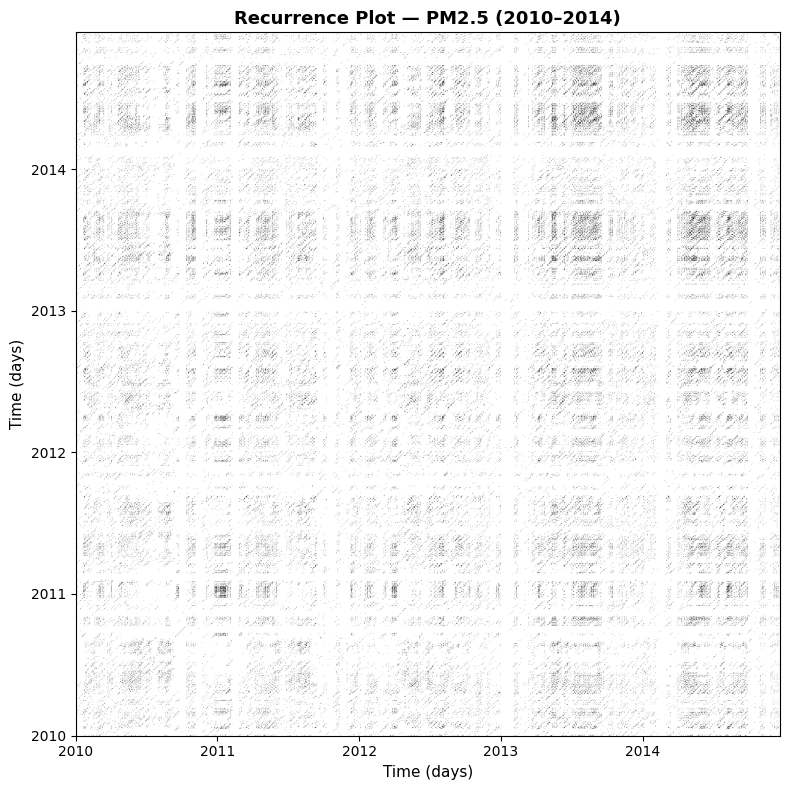

In [70]:
# Build the recurrence matrix
dist_matrix = cdist(X_pm25, X_pm25, 'euclidean')
R = (dist_matrix <= radius).astype(int)

# Remove the main diagonal (Theiler window = 1)
np.fill_diagonal(R, 0)

print(f"Recurrence matrix shape: {R.shape}")
print(f"Recurrence matrix is symmetric: {np.allclose(R, R.T)}")

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(R, cmap='binary', origin='lower', aspect='auto')

ax.set_title('Recurrence Plot — PM2.5 (2010–2014)', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Time (days)', fontsize=11)
ax.set_ylabel('Time (days)', fontsize=11)

# Add year markers on axes
year_positions = [0, 365, 730, 1095, 1460]
year_labels    = ['2010', '2011', '2012', '2013', '2014']
ax.set_xticks(year_positions)
ax.set_xticklabels(year_labels)
ax.set_yticks(year_positions)
ax.set_yticklabels(year_labels)

plt.tight_layout()
plt.savefig('fig_recurrence_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [71]:
def compute_rqa(R, min_diag=2, min_vert=2):
    """
    Compute all RQA measures from a recurrence matrix.
    """
    n = R.shape[0]
    
    # ── %REC ────────────────────────────────────────
    # Percentage of recurrent points (excluding diagonal)
    rec = R.sum() / (n * (n - 1)) * 100

    # ── Diagonal lines → DET, maxL, L, ENTR ─────────
    diag_lengths = []
    for offset in range(-(n-1), n):
        if offset == 0:
            continue
        diag = np.diag(R, offset)
        run  = 0
        for val in diag:
            if val:
                run += 1
            else:
                if run >= min_diag:
                    diag_lengths.append(run)
                run = 0
        if run >= min_diag:
            diag_lengths.append(run)

    if diag_lengths:
        diag_lengths = np.array(diag_lengths)
        det   = diag_lengths.sum() / R.sum() * 100
        maxL  = int(diag_lengths.max())
        avg_L = float(diag_lengths.mean())
        # Entropy of diagonal line length distribution
        counts = np.bincount(diag_lengths)
        probs  = counts[counts > 0] / counts[counts > 0].sum()
        entr   = -np.sum(probs * np.log(probs + 1e-12))
    else:
        det, maxL, avg_L, entr = 0, 0, 0, 0

    # ── Vertical lines → LAM, TT ─────────────────────
    vert_lengths = []
    for col in range(n):
        run = 0
        for row in range(n):
            if R[row, col]:
                run += 1
            else:
                if run >= min_vert:
                    vert_lengths.append(run)
                run = 0
        if run >= min_vert:
            vert_lengths.append(run)

    if vert_lengths:
        vert_lengths = np.array(vert_lengths)
        lam = vert_lengths.sum() / R.sum() * 100
        tt  = float(vert_lengths.mean())
    else:
        lam, tt = 0, 0

    return {
        '%REC' : round(rec,  4),
        '%DET' : round(det,  4),
        'maxL' : maxL,
        'L'    : round(avg_L, 4),
        'ENTR' : round(entr,  4),
        '%LAM' : round(lam,  4),
        'TT'   : round(tt,   4)
    }

# Run RQA
print("Computing RQA measures...")
rqa_results = compute_rqa(R)

print("\n===== RQA RESULTS — PM2.5 =====")
for measure, value in rqa_results.items():
    print(f"  {measure:6s} = {value}")

Computing RQA measures...

===== RQA RESULTS — PM2.5 =====
  %REC   = 3.051
  %DET   = 16.7427
  maxL   = 11
  L      = 2.1304
  ENTR   = 0.3885
  %LAM   = 32.6404
  TT     = 2.2789


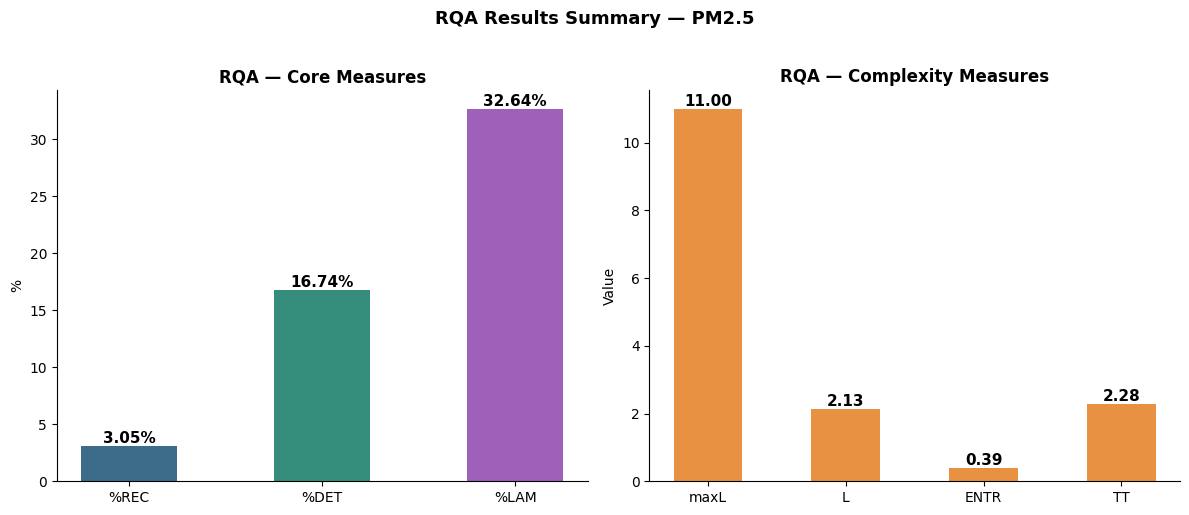

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left plot — core measures
measures1 = ['%REC', '%DET', '%LAM']
values1   = [rqa_results[m] for m in measures1]
colors1   = ['#1a5276', '#117a65', '#8e44ad']

bars = axes[0].bar(measures1, values1, color=colors1, alpha=0.85, width=0.5)
axes[0].set_title('RQA — Core Measures', fontsize=12, fontweight='bold')
axes[0].set_ylabel('%')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
# Add value labels on bars
for bar, val in zip(bars, values1):
    axes[0].text(bar.get_x() + bar.get_width()/2, 
                 bar.get_height() + 0.3,
                 f'{val:.2f}%', ha='center', fontsize=11, fontweight='bold')

# Right plot — complexity measures
measures2 = ['maxL', 'L', 'ENTR', 'TT']
values2   = [rqa_results[m] for m in measures2]
colors2   = ['#e67e22', '#e67e22', '#e67e22', '#e67e22']

bars2 = axes[1].bar(measures2, values2, color=colors2, alpha=0.85, width=0.5)
axes[1].set_title('RQA — Complexity Measures', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Value')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
for bar, val in zip(bars2, values2):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('RQA Results Summary — PM2.5', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_rqa_results.png', dpi=150, bbox_inches='tight')
plt.show()


PM2.5 embedded shape: (1814, 4)
Temp embedded shape:  (1814, 4)
Lengths match: True 

Building cross-recurrence matrix...
Cross-recurrence matrix shape: (1814, 1814)


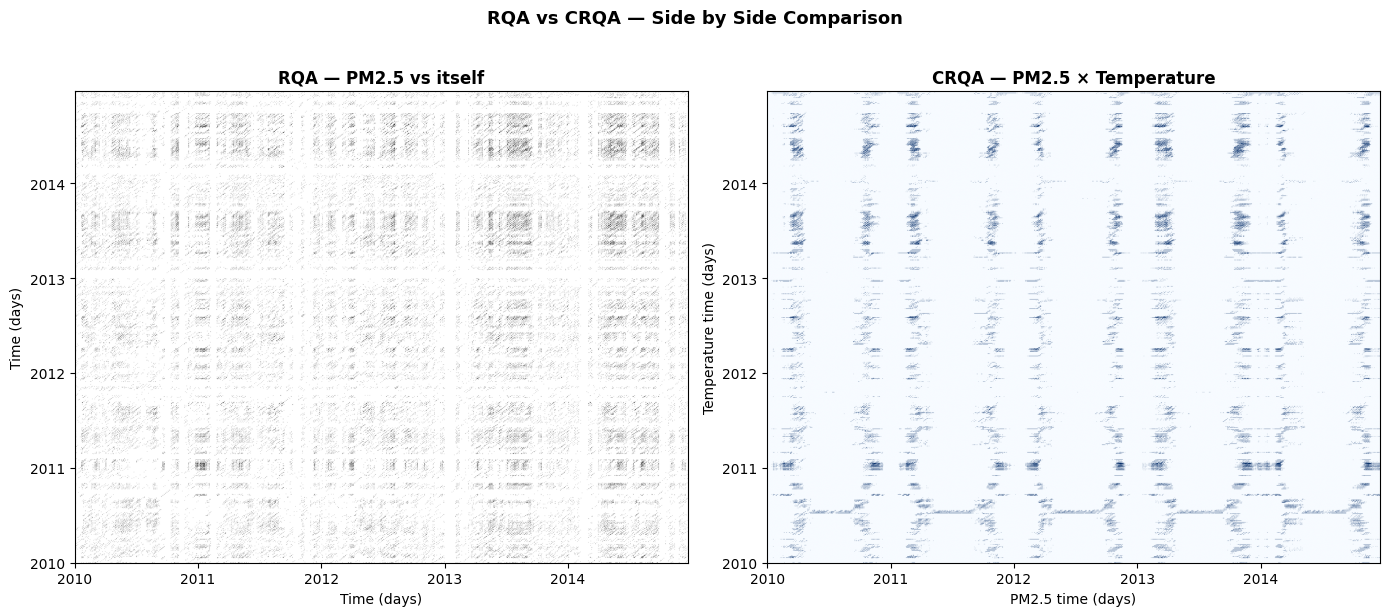

In [73]:
# Build embedded matrices for both signals
temp_vals = df_norm['temp'].values

def embed(ts, m, tau):
    L = len(ts) - (m - 1) * tau
    return np.array([ts[i*tau : i*tau + L] for i in range(m)]).T

# For CRQA — teacher says use the higher of the two tau estimates
# We'll use same M and tau as RQA for consistency
X_pm25 = embed(pm25_vals, m=m_opt, tau=tau)
X_temp  = embed(temp_vals, m=m_opt, tau=tau)

# Trim to same length (required for CRQA)
L = min(len(X_pm25), len(X_temp))
X_pm25 = X_pm25[:L]
X_temp  = X_temp[:L]

print(f"PM2.5 embedded shape: {X_pm25.shape}")
print(f"Temp embedded shape:  {X_temp.shape}")
print(f"Lengths match: {len(X_pm25) == len(X_temp)} ")

# Build CROSS-recurrence matrix
# Instead of comparing PM2.5 to itself, we compare PM2.5 to temperature
from scipy.spatial.distance import cdist

print("\nBuilding cross-recurrence matrix...")
cross_dist = cdist(X_pm25, X_temp, 'euclidean')
R_cross    = (cross_dist <= radius).astype(int)

print(f"Cross-recurrence matrix shape: {R_cross.shape}")

# Plot cross-recurrence plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left — original RQA for comparison
axes[0].imshow(R, cmap='binary', origin='lower', aspect='auto')
axes[0].set_title('RQA — PM2.5 vs itself', 
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Time (days)')
axes[0].set_ylabel('Time (days)')
year_pos = [0, 365, 730, 1095, 1460]
year_lab = ['2010','2011','2012','2013','2014']
axes[0].set_xticks(year_pos); axes[0].set_xticklabels(year_lab)
axes[0].set_yticks(year_pos); axes[0].set_yticklabels(year_lab)

# Right — CRQA
axes[1].imshow(R_cross, cmap='Blues', origin='lower', aspect='auto')
axes[1].set_title('CRQA — PM2.5 × Temperature', 
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('PM2.5 time (days)')
axes[1].set_ylabel('Temperature time (days)')
axes[1].set_xticks(year_pos); axes[1].set_xticklabels(year_lab)
axes[1].set_yticks(year_pos); axes[1].set_yticklabels(year_lab)

plt.suptitle('RQA vs CRQA — Side by Side Comparison', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_crqa_plot.png', dpi=150, bbox_inches='tight')
plt.show()


CRQA RESULTS — PM2.5 × Temperature
  %REC   = 2.2825
  %DET   = 34.5616
  maxL   = 16
  L      = 2.3413
  ENTR   = 0.7156
  %LAM   = 37.5243
  TT     = 2.3617
COMPARISON: RQA vs CRQA
Measure   RQA (PM2.5)  CRQA (PM2.5×T)   Difference
--------------------------------------------------
%REC            3.051          2.2825      -0.7685
%DET          16.7427         34.5616     +17.8189
maxL               11              16      +5.0000
L              2.1304          2.3413      +0.2109
ENTR           0.3885          0.7156      +0.3271
%LAM          32.6404         37.5243      +4.8839
TT             2.2789          2.3617      +0.0828


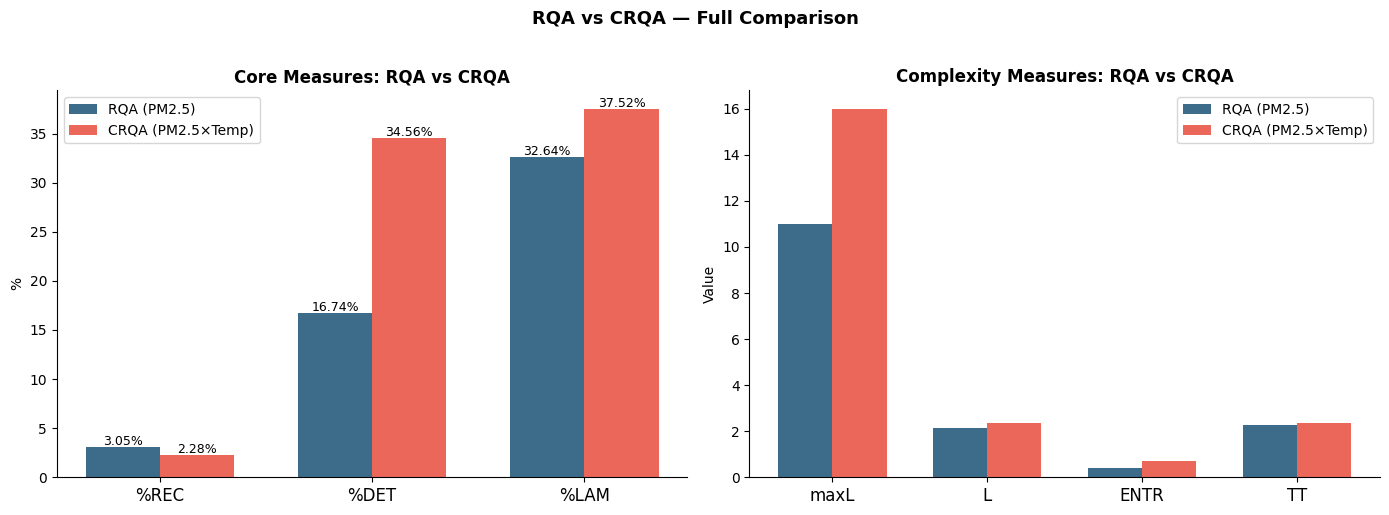

In [74]:
# Compute CRQA measures

crqa_results = compute_rqa(R_cross)

print("\nCRQA RESULTS — PM2.5 × Temperature")
for measure, value in crqa_results.items():
    print(f"  {measure:6s} = {value}")

# Compare RQA vs CRQA side by side
print("COMPARISON: RQA vs CRQA")
print(f"{'Measure':<8} {'RQA (PM2.5)':>12} {'CRQA (PM2.5×T)':>15} {'Difference':>12}")
print("-" * 50)
for measure in rqa_results:
    rqa_val  = rqa_results[measure]
    crqa_val = crqa_results[measure]
    diff     = crqa_val - rqa_val
    print(f"{measure:<8} {rqa_val:>12} {crqa_val:>15} {diff:>+12.4f}")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

measures1 = ['%REC', '%DET', '%LAM']
x         = np.arange(len(measures1))
w         = 0.35

# Core measures
axes[0].bar(x - w/2, [rqa_results[m]  for m in measures1], 
            w, label='RQA (PM2.5)', color='#1a5276', alpha=0.85)
axes[0].bar(x + w/2, [crqa_results[m] for m in measures1], 
            w, label='CRQA (PM2.5×Temp)', color='#e74c3c', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(measures1, fontsize=12)
axes[0].set_ylabel('%')
axes[0].set_title('Core Measures: RQA vs CRQA', 
                   fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Add value labels
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 f'{bar.get_height():.2f}%',
                 ha='center', fontsize=9)

# Complexity measures
measures2 = ['maxL', 'L', 'ENTR', 'TT']
x2        = np.arange(len(measures2))

axes[1].bar(x2 - w/2, [rqa_results[m]  for m in measures2], 
            w, label='RQA (PM2.5)', color='#1a5276', alpha=0.85)
axes[1].bar(x2 + w/2, [crqa_results[m] for m in measures2], 
            w, label='CRQA (PM2.5×Temp)', color='#e74c3c', alpha=0.85)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(measures2, fontsize=12)
axes[1].set_ylabel('Value')
axes[1].set_title('Complexity Measures: RQA vs CRQA', 
                   fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('RQA vs CRQA — Full Comparison', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_rqa_vs_crqa.png', dpi=150, bbox_inches='tight')
plt.show()


Peak lag = 47 days
→ Temperature LEADS PM2.5 by 47 days


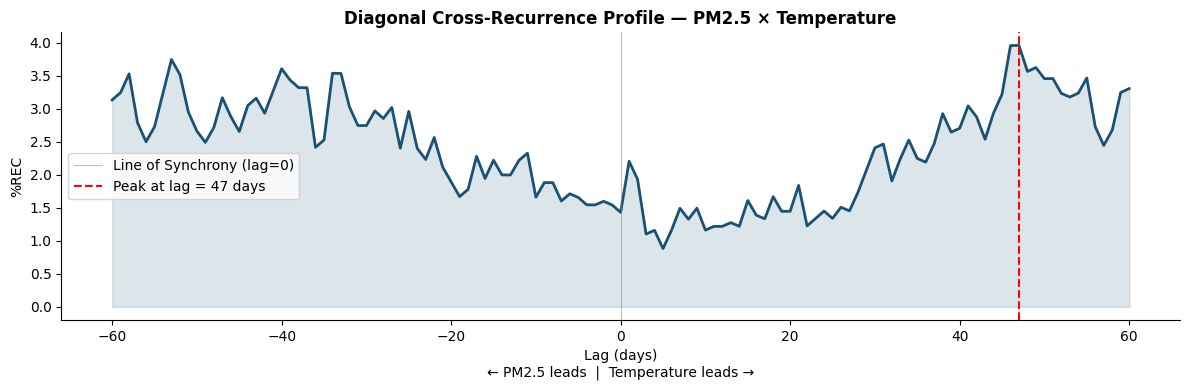

In [75]:
def compute_dcrp(ts1, ts2, m, tau, radius, max_lag=60):
    """
    Diagonal Cross-Recurrence Profile.
    Sweeps across lags to find leader-follower relationship.
    Peak at lag=0 → simultaneous coupling
    Peak at lag<0 → ts1 leads ts2
    Peak at lag>0 → ts2 leads ts1
    """
    def embed(ts, m, tau):
        L = len(ts) - (m - 1) * tau
        return np.array([ts[i*tau : i*tau + L] for i in range(m)]).T
    
    X1 = embed(ts1, m, tau)
    X2 = embed(ts2, m, tau)
    L  = min(len(X1), len(X2))
    X1, X2 = X1[:L], X2[:L]
    
    lags    = range(-max_lag, max_lag + 1)
    profile = []
    
    for lag in lags:
        if lag >= 0:
            a = X1[:L - lag] if lag > 0 else X1
            b = X2[lag:]     if lag > 0 else X2
        else:
            a = X1[-lag:]
            b = X2[:L + lag]
        
        ML   = min(len(a), len(b))
        dist = np.sqrt(np.sum((a[:ML] - b[:ML])**2, axis=1))
        rec  = (dist <= radius).mean() * 100
        profile.append(rec)
    
    return list(lags), profile


lags, profile = compute_dcrp(
    pm25_vals, temp_vals,
    m=m_opt, tau=tau,
    radius=radius, max_lag=60
)

# Find peak lag
peak_lag = lags[np.argmax(profile)]
print(f"Peak lag = {peak_lag} days")

if peak_lag < 0:
    print(f"→ PM2.5 LEADS temperature by {abs(peak_lag)} days")
elif peak_lag > 0:
    print(f"→ Temperature LEADS PM2.5 by {peak_lag} days")
else:
    print("→ PM2.5 and temperature are synchronously coupled")

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(lags, profile, color='#1a5276', lw=2)
ax.axvline(0, color='grey', ls='-', lw=0.8, 
           alpha=0.5, label='Line of Synchrony (lag=0)')
ax.axvline(peak_lag, color='red', ls='--', lw=1.5,
           label=f'Peak at lag = {peak_lag} days')
ax.fill_between(lags, profile, alpha=0.15, color='#1a5276')
ax.set_title('Diagonal Cross-Recurrence Profile — PM2.5 × Temperature',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Lag (days)\n← PM2.5 leads  |  Temperature leads →')
ax.set_ylabel('%REC')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig_dcrp.png', dpi=150, bbox_inches='tight')
plt.show()


Windows computed: 58
              %REC     %DET  maxL       L    ENTR     %LAM      TT
2010-02-15  2.8971   4.5977     2  2.0000 -0.0000  19.5402  2.0000
2010-03-17  2.4975   8.0000     2  2.0000 -0.0000   6.6667  2.0000
2010-04-16  2.9304   5.6818     3  2.5000  0.6931  13.6364  2.1818
2010-05-16  5.6277  20.1183     3  2.2667  0.5799  29.2899  2.0625
2010-06-15  6.5934  17.1717     3  2.2667  0.5799  23.4848  2.0217


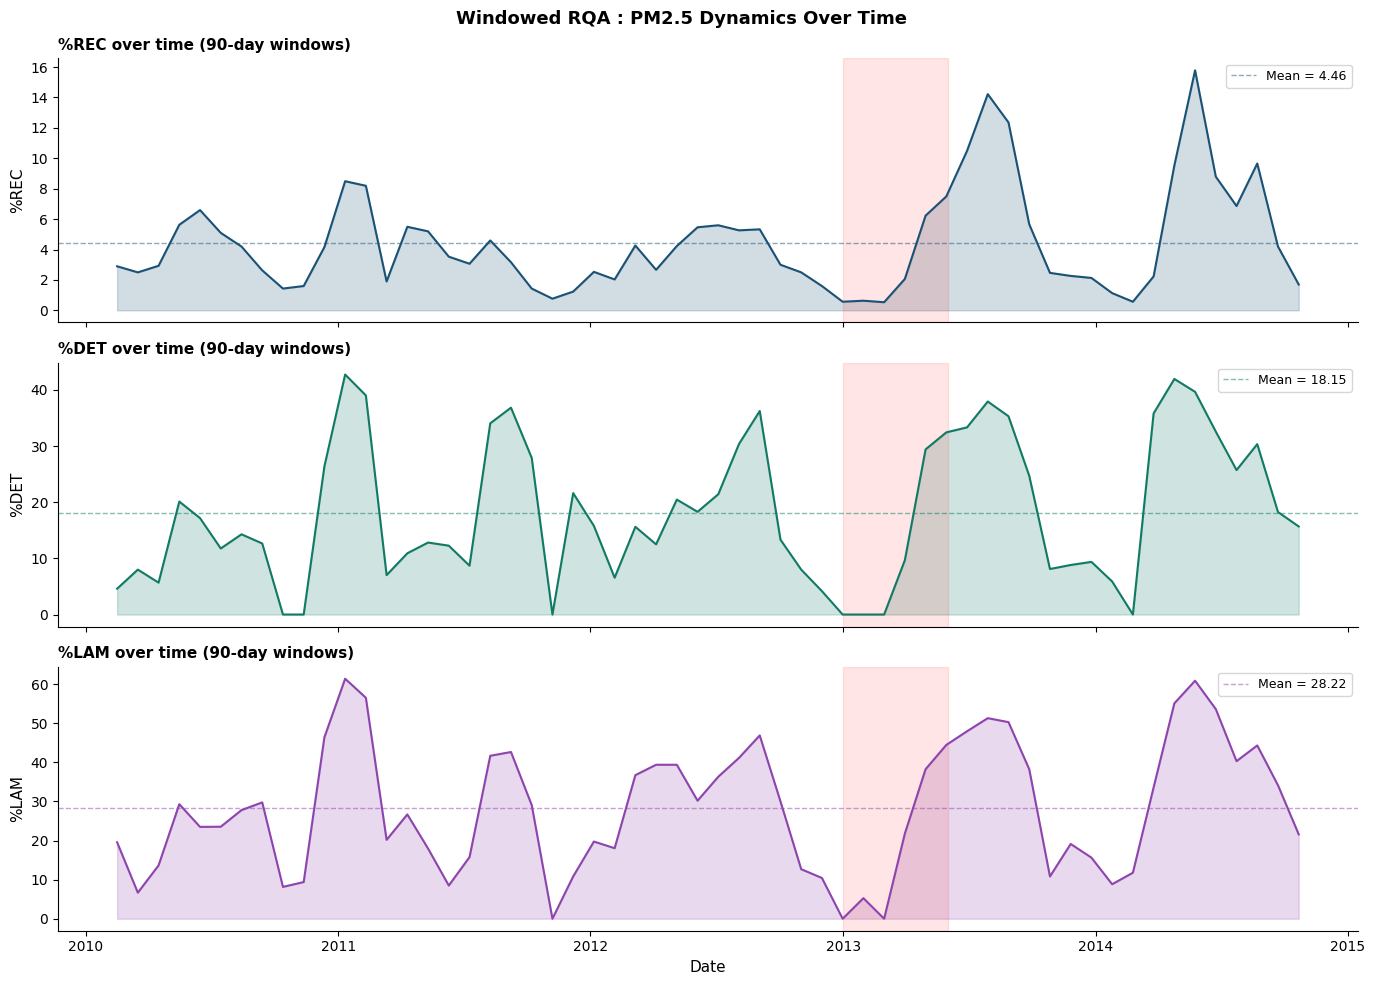

In [76]:


window_size = 90   # 90-day windows
step_size   = 30   # move 30 days at a time

win_records = []
win_dates   = []

for start in range(0, len(pm25_vals) - window_size, step_size):
    end = start + window_size
    seg = pm25_vals[start:end]
    
    # Embed this window
    X_w  = embed(seg, m=m_opt, tau=tau)
    
    # Build recurrence matrix for this window
    dist_w = cdist(X_w, X_w, 'euclidean')
    np.fill_diagonal(dist_w, np.inf)
    R_w    = (dist_w <= radius).astype(int)
    np.fill_diagonal(R_w, 0)
    
    # Compute RQA measures
    res = compute_rqa(R_w)
    win_records.append(res)
    
    # Store the middle date of this window
    mid_idx = start + window_size // 2
    win_dates.append(df_daily.index[mid_idx])

win_df = pd.DataFrame(win_records, index=win_dates)

print(f"Windows computed: {len(win_df)}")
print(win_df.head())

# Plot
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

measures = ['%REC', '%DET', '%LAM']
colors   = ['#1a5276', '#117a65', '#8e44ad']

for ax, measure, color in zip(axes, measures, colors):
    ax.plot(win_df.index, win_df[measure], 
            color=color, lw=1.5)
    ax.fill_between(win_df.index, win_df[measure], 
                    alpha=0.2, color=color)
    ax.set_ylabel(measure, fontsize=11)
    ax.set_title(f'{measure} over time (90-day windows)', 
                 fontsize=11, fontweight='bold', loc='left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add horizontal mean line
    ax.axhline(win_df[measure].mean(), color=color, 
               ls='--', lw=1, alpha=0.5, 
               label=f'Mean = {win_df[measure].mean():.2f}')
    ax.legend(fontsize=9, loc='upper right')

# Mark the 2013 Beijing pollution event
for ax in axes:
    ax.axvspan(pd.Timestamp('2013-01-01'), 
               pd.Timestamp('2013-06-01'),
               alpha=0.1, color='red', 
               label='2013 pollution event')

axes[-1].set_xlabel('Date', fontsize=11)
plt.suptitle('Windowed RQA : PM2.5 Dynamics Over Time', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_windowed_rqa.png', dpi=150, bbox_inches='tight')
plt.show()


Multivariate state matrix shape: (1826, 4)
(1826 days × 4 variables)

Finding mdRQA radius...
mdRQA radius = 0.5954
Actual %REC  = 3.18%

Computing mdRQA measures...
 mdRQA RESULTS — All 4 Variables 
  %REC   = 3.1802
  %DET   = 40.7292
  maxL   = 12
  L      = 2.3914
  ENTR   = 0.8219
  %LAM   = 55.0605
  TT     = 2.657


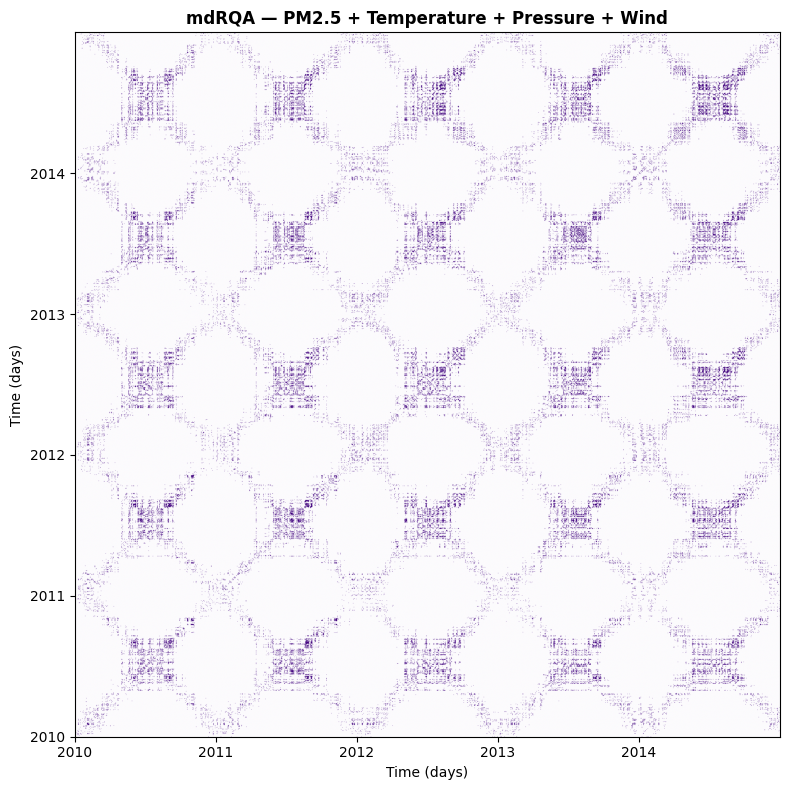

In [77]:

# Each row = one day's state of the full system [pm25, temp, pressure, wind]
X_md = np.column_stack([
    df_norm['pm25'].values,
    df_norm['temp'].values,
    df_norm['pressure'].values,
    df_norm['wind'].values
])

print(f"Multivariate state matrix shape: {X_md.shape}")
print("(1826 days × 4 variables)")

# Find radius for ~3% recurrence in multivariate space
print("\nFinding mdRQA radius...")
lo, hi = 0.01, 10.0
for _ in range(50):
    mid      = (lo + hi) / 2
    dist_md  = cdist(X_md, X_md, 'euclidean')
    np.fill_diagonal(dist_md, np.inf)
    rec      = (dist_md <= mid).sum() / (len(X_md) * (len(X_md)-1)) * 100
    if abs(rec - 3.0) < 0.3:
        break
    if rec < 3.0:
        lo = mid
    else:
        hi = mid

radius_md = mid
print(f"mdRQA radius = {radius_md:.4f}")
print(f"Actual %REC  = {rec:.2f}%")

# Build multivariate recurrence matrix
R_md = (dist_md <= radius_md).astype(int)
np.fill_diagonal(R_md, 0)

# Compute mdRQA measures
print("\nComputing mdRQA measures...")
mdrqa_results = compute_rqa(R_md)

print(" mdRQA RESULTS — All 4 Variables ")
for measure, value in mdrqa_results.items():
    print(f"  {measure:6s} = {value}")

# Plot mdRQA recurrence plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(R_md, cmap='Purples', origin='lower', aspect='auto')
ax.set_title('mdRQA — PM2.5 + Temperature + Pressure + Wind',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Time (days)')
year_pos = [0, 365, 730, 1095, 1460]
year_lab = ['2010','2011','2012','2013','2014']
ax.set_xticks(year_pos); ax.set_xticklabels(year_lab)
ax.set_yticks(year_pos); ax.set_yticklabels(year_lab)
plt.tight_layout()
plt.savefig('fig_mdrqa_plot.png', dpi=150, bbox_inches='tight')
plt.show()


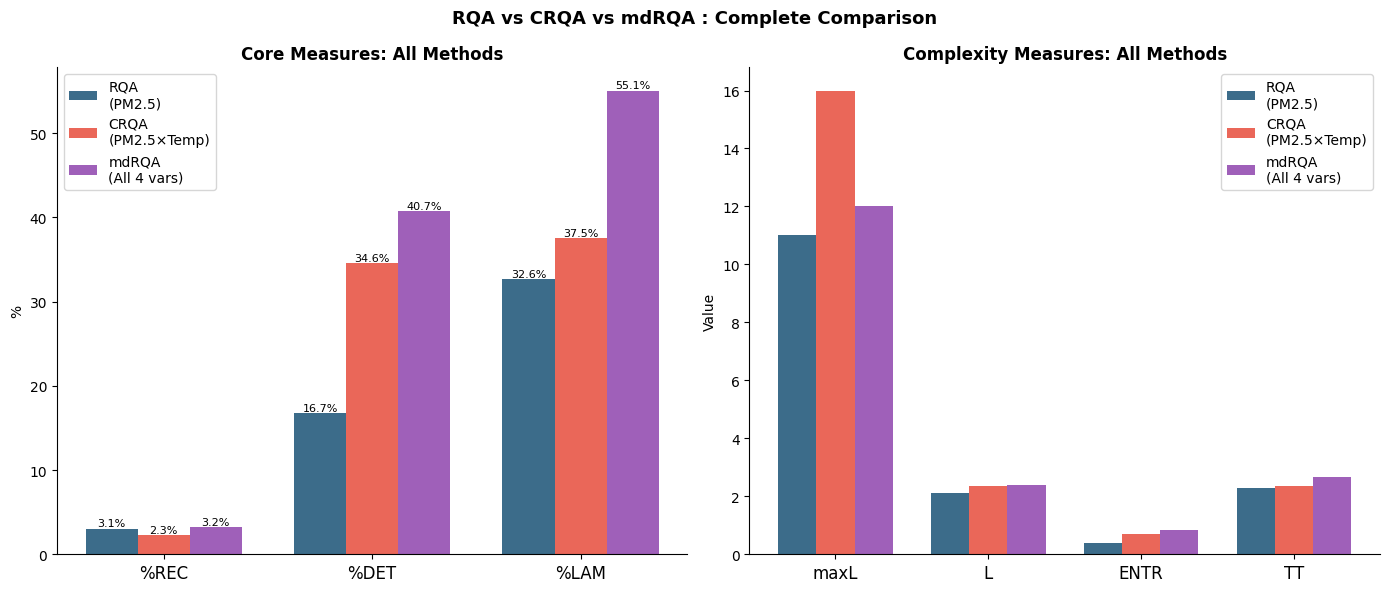

Measure         RQA       CRQA      mdRQA
------------------------------------------
%REC          3.051     2.2825     3.1802
%DET        16.7427    34.5616    40.7292
maxL             11         16         12
L            2.1304     2.3413     2.3914
ENTR         0.3885     0.7156     0.8219
%LAM        32.6404    37.5243    55.0605
TT           2.2789     2.3617      2.657


In [78]:
# Complete comparison of all three methods
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

methods  = ['RQA\n(PM2.5)', 'CRQA\n(PM2.5×Temp)', 'mdRQA\n(All 4 vars)']
colors   = ['#1a5276', '#e74c3c', '#8e44ad']

# Core measures
measures1 = ['%REC', '%DET', '%LAM']
x         = np.arange(len(measures1))
w         = 0.25

all_results = [rqa_results, crqa_results, mdrqa_results]

for i, (res, color, method) in enumerate(zip(all_results, colors, methods)):
    vals = [res[m] for m in measures1]
    bars = axes[0].bar(x + i*w, vals, w, 
                       label=method, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.3,
                     f'{val:.1f}%', ha='center', fontsize=8)

axes[0].set_xticks(x + w)
axes[0].set_xticklabels(measures1, fontsize=12)
axes[0].set_ylabel('%')
axes[0].set_title('Core Measures: All Methods', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Complexity measures
measures2 = ['maxL', 'L', 'ENTR', 'TT']
x2        = np.arange(len(measures2))

for i, (res, color, method) in enumerate(zip(all_results, colors, methods)):
    vals = [res[m] for m in measures2]
    axes[1].bar(x2 + i*w, vals, w,
                label=method, color=color, alpha=0.85)

axes[1].set_xticks(x2 + w)
axes[1].set_xticklabels(measures2, fontsize=12)
axes[1].set_ylabel('Value')
axes[1].set_title('Complexity Measures: All Methods', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('RQA vs CRQA vs mdRQA : Complete Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_all_methods_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print final summary table

print(f"{'Measure':<8} {'RQA':>10} {'CRQA':>10} {'mdRQA':>10}")
print("-" * 42)
for m in rqa_results:
    print(f"{m:<8} {rqa_results[m]:>10} {crqa_results[m]:>10} {mdrqa_results[m]:>10}")

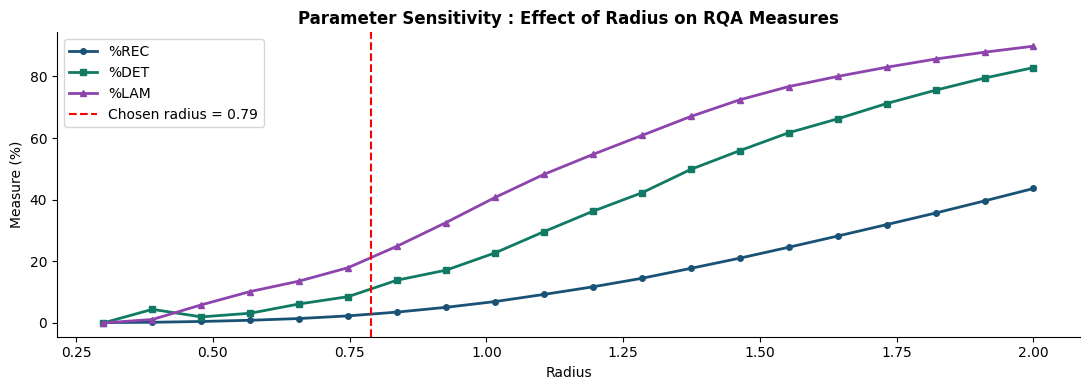

In [79]:


radii    = np.linspace(0.3, 2.0, 20)
sens_rec = []
sens_det = []
sens_lam = []

for r in radii:
    dist_s = cdist(X_pm25[:300], X_pm25[:300], 'euclidean')
    np.fill_diagonal(dist_s, np.inf)
    R_s    = (dist_s <= r).astype(int)
    np.fill_diagonal(R_s, 0)
    res    = compute_rqa(R_s)
    sens_rec.append(res['%REC'])
    sens_det.append(res['%DET'])
    sens_lam.append(res['%LAM'])

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(radii, sens_rec, label='%REC', color='#1a5276', lw=2, marker='o', ms=4)
ax.plot(radii, sens_det, label='%DET', color='#117a65', lw=2, marker='s', ms=4)
ax.plot(radii, sens_lam, label='%LAM', color='#8e44ad', lw=2, marker='^', ms=4)
ax.axvline(radius, color='red', ls='--', lw=1.5, 
           label=f'Chosen radius = {radius:.2f}')
ax.set_title('Parameter Sensitivity : Effect of Radius on RQA Measures',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Radius')
ax.set_ylabel('Measure (%)')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
